In [1]:
import pandas as pd
import numpy as np # linear algebra
import seaborn as sns # Plots

from sklearn import datasets
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn import tree
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler

In [3]:
# Datensatz aus Bibliothek laden (Standarddatensatz)
iris = datasets.load_iris()
type(iris)



X = iris.data # Input Variablen
y = iris.target # Output Variable
df_iris = pd.DataFrame(X, columns = iris.feature_names) # Dataframe konstruieren
df_iris['target'] = iris.target

df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Decision Tree I
clf = tree.DecisionTreeClassifier() ist ein Objekt der Klasse DecisionTreeClassifier

Die Methode fit() bekommt ein array X mit den Input Variablen des Trainingsdatensatzes und y einem Vektor der Output-Variablen des Trainingsdatensatzes um den Baum zu trainieren

In [5]:
# Modelltraining

X = df_iris.drop("target",axis=1)
y = df_iris["target"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3, random_state=1)

dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [6]:
# Da in der Output Variablen nicht nur zwischen 0 und 1 unterschieden wird, diese also nicht binär ist,
# handelt es sich um eine Multiclass-Klassifikation
np.unique(y_train)

array([0, 1, 2])

[Text(0.4, 0.9, 'x[3] <= 0.8\ngini = 0.665\nsamples = 105\nvalue = [36, 32, 37]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 36\nvalue = [36, 0, 0]'),
 Text(0.5, 0.7, 'x[3] <= 1.65\ngini = 0.497\nsamples = 69\nvalue = [0, 32, 37]'),
 Text(0.2, 0.5, 'x[2] <= 5.0\ngini = 0.161\nsamples = 34\nvalue = [0, 31, 3]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.3, 0.3, 'x[0] <= 6.05\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.5, 'x[2] <= 4.85\ngini = 0.056\nsamples = 35\nvalue = [0, 1, 34]'),
 Text(0.7, 0.3, 'x[1] <= 3.1\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 31\nvalue = [0, 0, 31]')]

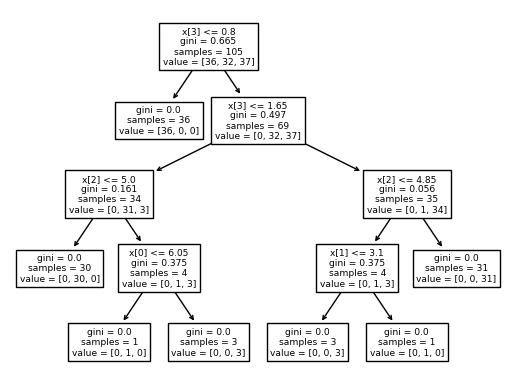

In [7]:
# Plot des trainierten Baumes
tree.plot_tree(dt)

# Resultierender Baum
x[3]<=0.8 entspricht der petal width, damit lässt sich die Klasse 0 bereits perfekt extrahieren, Gini-Index ist in diesem Blatt bereits = 0

Das 2. Kriterium ist petal width<=1.65, der Gini Index ist hier 0.497, die verbleibenden Klassen sind nahezu gleichverteilt [0, 32, 77]

In einigen der Blätter sind nur noch wenige Beobachtungen enthalten z.B. [0, 1, 0], [0, 0, 3]

Es könnte sein das das Modell hier Overfitted, dazu schauen wir und Trainings- und Testfehler an

In [8]:
y_pred_train = dt.predict(X_train)
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)

print('Accuracy of Decision Tree-Train: ', accuracy_score(y_pred_train, y_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(y_pred, y_test))

Accuracy of Decision Tree-Train:  1.0
Accuracy of Decision Tree-Test:  0.9555555555555556


In [9]:
print('Confusion Matrix - Train:','\n',confusion_matrix(y_train,y_pred_train))

Confusion Matrix - Train: 
 [[36  0  0]
 [ 0 32  0]
 [ 0  0 37]]


# Ergebnisinterpretation
Die Genauigkeit im Trainingsdatensatz ist 1, d.h. alle Trainingsdaten können perfekt zugeordnet werden

Angewandt auf die Testdaten die im Training nicht verwendet wurden ist die Accuracy 0.956, also ebenfalls sehr hoch.

Die Confusion Matrix zeigt, dass für die Klasse 1 und 2 jeweils eine Beobachtung falsch klassifiziert wurde

In [10]:
print('Confusion Matrix - Test:','\n',confusion_matrix(y_test,y_pred))

Confusion Matrix - Test: 
 [[14  0  0]
 [ 0 17  1]
 [ 0  1 12]]


In [11]:
print('accuracy = (14+17+12)/(14+17+12+1+1)=', (14+17+12)/(14+17+12+1+1))

accuracy = (14+17+12)/(14+17+12+1+1)= 0.9555555555555556


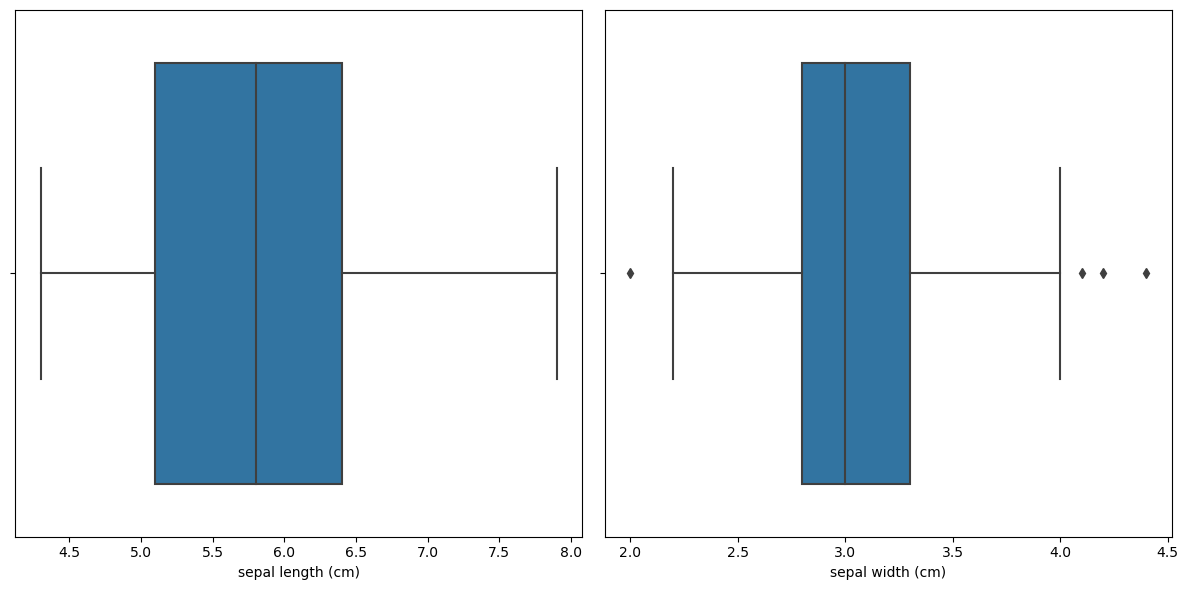

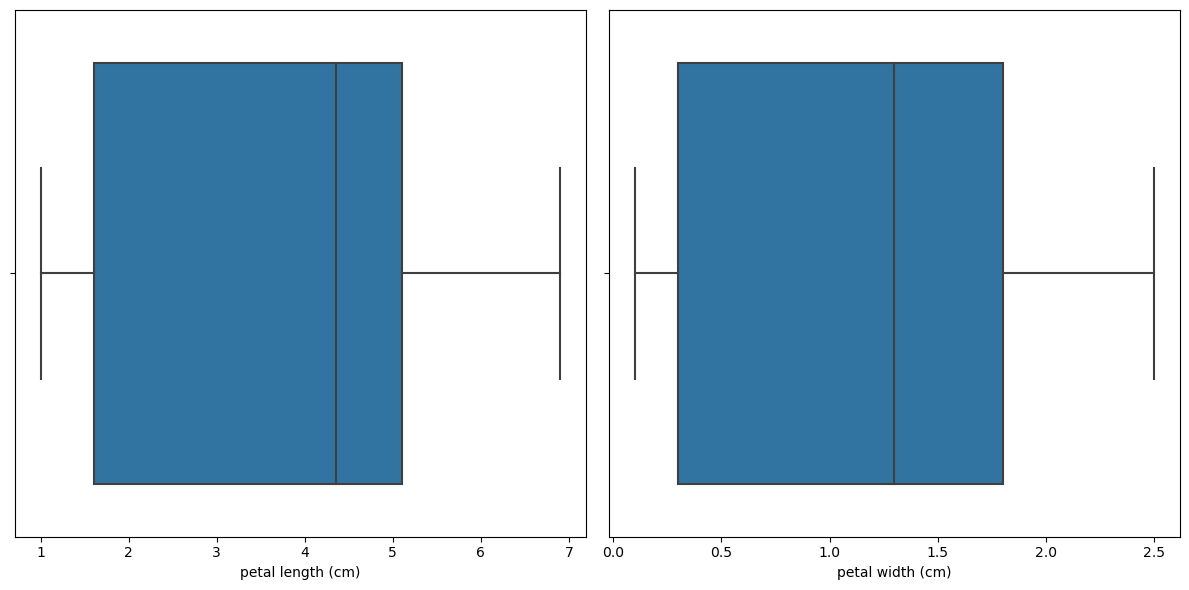

In [28]:
# Boxplots to visualize distributions
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x="sepal length (cm)", data=df_iris)
plt.subplot(1, 2, 2)
sns.boxplot(x="sepal width (cm)", data=df_iris)
plt.tight_layout()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x="petal length (cm)", data=df_iris)
plt.subplot(1, 2, 2)
sns.boxplot(x="petal width (cm)", data=df_iris)
plt.tight_layout()

# Outlier bei sepal witdth (cm)
Filtern nach den Quantilen

In [29]:
# Outlier anhand des 0.25 und 0.75 Quantils entfernen 'sepal width (cm)'
q1 = df_iris['sepal width (cm)'].quantile(0.05) # Quantil 1
q3 = df_iris['sepal width (cm)'].quantile(0.95) # Quantil 2
iqr = q3 - q1 # interquantilsabstand
df_iris = df_iris[(df_iris['sepal width (cm)'] >= q1) & (df_iris['sepal width (cm)'] <= q3)]
df_iris.shape # To find out the number of rows and column after outlier treatment

(136, 5)

<Axes: xlabel='sepal width (cm)'>

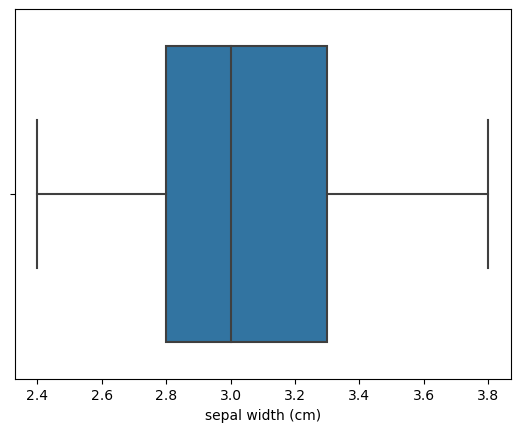

In [30]:
sns.boxplot(x="sepal width (cm)", data=df_iris)

# Decision Tree II

In [12]:
# Splitting the data into train and test sets
X = df_iris.drop("target",axis=1)
y = df_iris["target"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3, random_state= 1)

In [13]:
X_train.shape

(105, 4)

In [14]:
X_test.shape

(45, 4)

In [15]:
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)

In [16]:
print('Accuracy of Decision Tree-Train: ', accuracy_score(y_pred_train, y_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(y_pred, y_test))

Accuracy of Decision Tree-Train:  1.0
Accuracy of Decision Tree-Test:  0.9555555555555556


[Text(0.4, 0.9, 'x[3] <= 0.8\ngini = 0.665\nsamples = 105\nvalue = [36, 32, 37]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 36\nvalue = [36, 0, 0]'),
 Text(0.5, 0.7, 'x[3] <= 1.65\ngini = 0.497\nsamples = 69\nvalue = [0, 32, 37]'),
 Text(0.2, 0.5, 'x[2] <= 5.0\ngini = 0.161\nsamples = 34\nvalue = [0, 31, 3]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.3, 0.3, 'x[0] <= 6.05\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.5, 'x[2] <= 4.85\ngini = 0.056\nsamples = 35\nvalue = [0, 1, 34]'),
 Text(0.7, 0.3, 'x[1] <= 3.1\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 31\nvalue = [0, 0, 31]')]

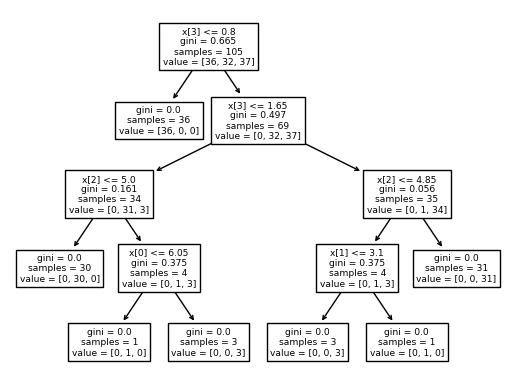

In [17]:
tree.plot_tree(dt)

In [18]:
#Classification for test before hyperparameter tuning
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [19]:
# Hyperparameter Tuning of DTC

dt = DecisionTreeClassifier(random_state=1)

params = {'max_depth' : [2,3,4,5],
        'min_samples_split': [2,3,4,5],
        'min_samples_leaf': [1,2,3,4,5]}

gsearch = GridSearchCV(dt, param_grid=params, cv=3)

gsearch.fit(X,y)

gsearch.best_params_

{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [20]:
# Passing best parameter for the Hyperparameter Tuning
dt = DecisionTreeClassifier(**gsearch.best_params_, random_state=1)

dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
y_prob_train = dt.predict_proba(X_train)[:,1]

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

In [21]:
print('Confusion Matrix - Train:','\n',confusion_matrix(y_train,y_pred_train))
print('\n','Confusion Matrix - Test:','\n',confusion_matrix(y_test,y_pred))

Confusion Matrix - Train: 
 [[36  0  0]
 [ 0 32  0]
 [ 0  0 37]]

 Confusion Matrix - Test: 
 [[14  0  0]
 [ 0 17  1]
 [ 0  1 12]]


In [22]:
#Classification for test after hyperparameter tuning
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [23]:
print('Accuracy of Decision Tree-Train: ', accuracy_score(y_pred_train, y_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(y_pred, y_test))

Accuracy of Decision Tree-Train:  1.0
Accuracy of Decision Tree-Test:  0.9555555555555556


In [24]:
# Cross Validation Error
# Initialize the Decision Tree Classifier
# Decision Tree Classifier from above dt

# Perform 10-fold cross-validation
cv_scores = cross_val_score(dt, X, y, cv=10, scoring='accuracy')

# Calculate the cross-validation error
cv_error = 1 - np.mean(cv_scores)

# Print the cross-validation error
print(f'Cross-validation error: {cv_error:.4f}')

Cross-validation error: 0.0467
